In [129]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

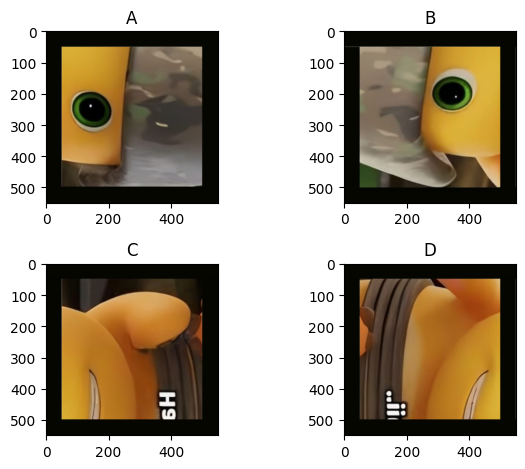

In [130]:
import matplotlib.pyplot as plt

dino1 = plt.imread("Assets/Dino-A.png")
dino2 = plt.imread("Assets/Dino-B.png")
dino3 = plt.imread("Assets/Dino-C.png")
dino4 = plt.imread("Assets/Dino-D.png")
kacamata = plt.imread("Assets/Kacamata.png")
uang = plt.imread("Assets/money.png")
udud = plt.imread("Assets/udud.png")

plt.subplot(2, 2, 1)
plt.imshow(dino1, cmap='gray')
plt.title("A")

plt.subplot(2, 2, 2)
plt.imshow(dino2, cmap='gray')
plt.title("B")

plt.subplot(2, 2, 3)
plt.imshow(dino3, cmap='gray')
plt.title("C")

plt.subplot(2, 2, 4)
plt.imshow(dino4, cmap='gray')
plt.title("D")

plt.tight_layout()
plt.show()

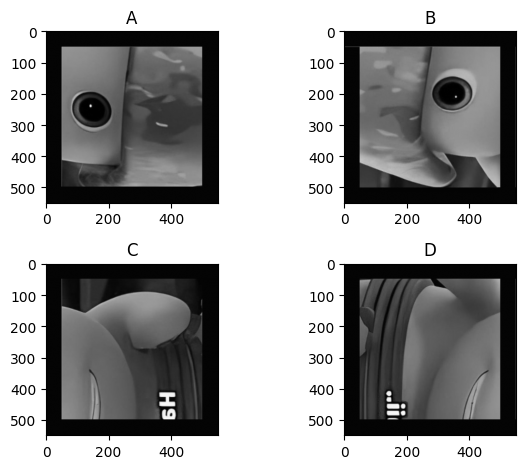

In [131]:
dino1Grey = cv.cvtColor(dino1, cv.COLOR_BGR2GRAY)
plt.subplot(2, 2, 1)
plt.imshow(dino1Grey, cmap='gray')
plt.title("A")

dino2Grey = cv.cvtColor(dino2, cv.COLOR_BGR2GRAY)
plt.subplot(2, 2, 2)
plt.imshow(dino2Grey, cmap='gray')
plt.title("B")

dino3Grey = cv.cvtColor(dino3, cv.COLOR_BGR2GRAY)
plt.subplot(2, 2, 3)
plt.imshow(dino3Grey, cmap='gray')
plt.title("C")

dino4Grey = cv.cvtColor(dino4, cv.COLOR_BGR2GRAY)
plt.subplot(2, 2, 4)
plt.imshow(dino4Grey, cmap='gray')
plt.title("D")

plt.tight_layout()

In [132]:
def flip(image, mode='X'): 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            if mode == 'X': 
                hasil[i, j] = image[i, w - 1 - j] 
            elif mode == 'Y': 
                hasil[i, j] = image[h - 1 - i, j] 
    return hasil 

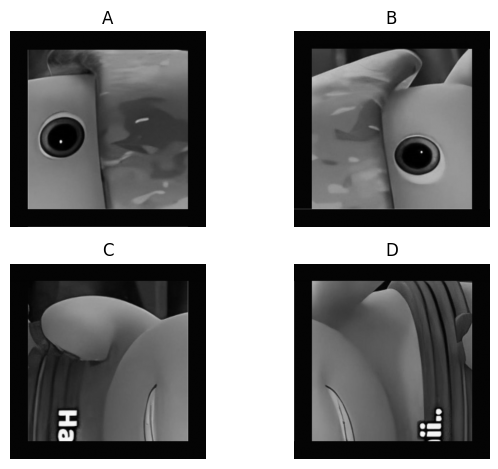

In [133]:
dino1 = flip(dino1Grey, mode='Y')
dino2 = flip(dino2Grey, mode='Y')
dino3 = flip(dino3Grey, mode='X')
dino4 = flip(dino4Grey, mode='X')

plt.subplot(2, 2, 1)
plt.imshow(dino1, cmap='gray')
plt.title("A")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(dino2, cmap='gray')
plt.title("B")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(dino3, cmap='gray')
plt.title("C")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(dino4, cmap='gray')
plt.title("D")
plt.axis('off')

plt.tight_layout()
plt.show()

In [134]:

def rotasikan(image, val): 
    h, w = image.shape 
    val = int(val) % 360  
    if val == 0: return image 
    elif val == 90: 
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[j, h - 1 - i] = image[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(image, dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[w - 1 - j, i] = image[i, j] 
        return rot 
    return image 

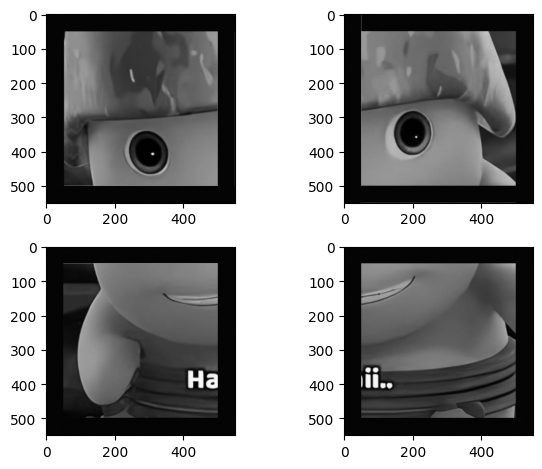

In [135]:
dinoR1 = rotasikan(dino1, 270)
dinoR2 = rotasikan(dino2, 90)
dinoR3 = rotasikan(dino3, 270)
dinoR4 = rotasikan(dino4, 90)

plt.subplot(2, 2, 1)
plt.imshow(dinoR1, cmap='gray')

plt.subplot(2, 2, 2)
plt.imshow(dinoR2, cmap='gray')

plt.subplot(2, 2, 3)
plt.imshow(dinoR3, cmap='gray')

plt.subplot(2, 2, 4)
plt.imshow(dinoR4, cmap='gray')

plt.tight_layout()
plt.show()

In [136]:
def translasi(image, geser_kolom_x=0, geser_baris_y=0): 
    image = np.array(image) 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_baris_y 
            new_j = j + geser_kolom_x 
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = image[i, j] 
    return hasil

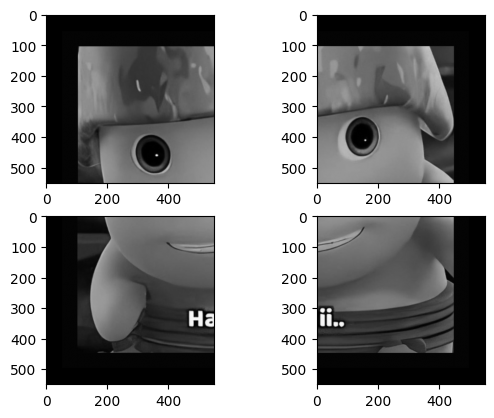

In [137]:
n = 52

dinoT1  = translasi(dinoR1, geser_kolom_x=n, geser_baris_y=n)
dinoT2 = translasi(dinoR2, geser_kolom_x=-n, geser_baris_y=n)
dinoT3 = translasi(dinoR3, geser_kolom_x=n, geser_baris_y=-n)
dinoT4 = translasi(dinoR4, geser_kolom_x=-n, geser_baris_y=-n)

plt.subplot(2, 2, 1)
plt.imshow(dinoT1, cmap='gray')
plt.subplot(2, 2, 2)
plt.imshow(dinoT2, cmap='gray')
plt.subplot(2, 2, 3)
plt.imshow(dinoT3, cmap='gray')
plt.subplot(2, 2, 4)
plt.imshow(dinoT4, cmap='gray')

plt.show()

In [138]:
def dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    # Cek apakah gambar punya channel warna atau tidak
    if len(image.shape) == 3:
        h, w, c = image.shape
        dilated = np.zeros((h * 2, w * 2, c), dtype=image.dtype) # Tambah channel c
    else:
        h, w = image.shape
        dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)

    for y in range(h * 2):
        for x in range(w * 2):
            # Gunakan penulisan indeks [y, x] yang lebih standar untuk NumPy
            dilated[y, x] = image[int(y / 2), int(x / 2)]
            
    # Normalisasi (crop) sisi luar
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    
    return dilated[sy:ey, sx:ex]

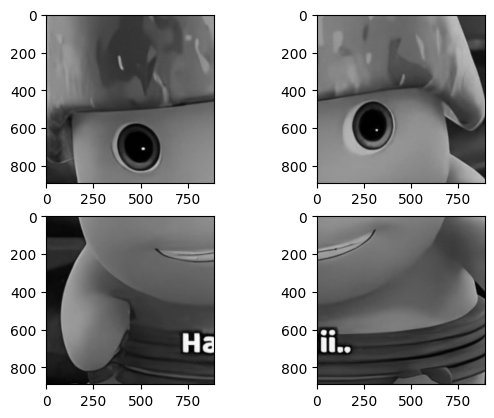

In [139]:
n = 210
dinoD1 = dilatasi(dinoT1, n, 0, n, 0)
dinoD2 = dilatasi(dinoT2, n, 0, 0, n)
dinoD3 = dilatasi(dinoT3, 0, n, n, 0)
dinoD4 = dilatasi(dinoT4, 0, n, 0, n)

plt.subplot(2, 2, 1)
plt.imshow(dinoD1, cmap='gray')

plt.subplot(2, 2, 2)
plt.imshow(dinoD2, cmap='gray')

plt.subplot(2, 2, 3)
plt.imshow(dinoD3, cmap='gray')

plt.subplot(2, 2, 4)
plt.imshow(dinoD4, cmap='gray')

plt.show()

In [140]:
# Tipe b: penyatuan sumbu horizontal
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    
    # PERBAIKAN: Gunakan dtype dari citra aslinya
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

# Tipe c: penyatuan sumbu vertikal
def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    
    # PERBAIKAN: Gunakan dtype dari citra aslinya
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

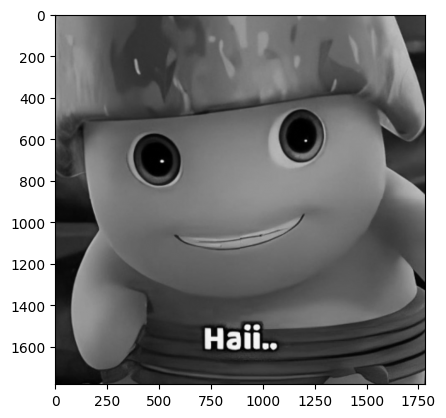

In [141]:
merger1 = fungsi_dua_b (dinoD1, dinoD2)
merger2 = fungsi_dua_b (dinoD3, dinoD4)
mergered = fungsi_dua_c (merger1, merger2)

plt.imshow(mergered, cmap='gray')
plt.show()

In [142]:
def gabung(citra_1, citra_2): 
    return citra_1 + citra_2

In [166]:
step1 = gabung(mergered, kacamata)
step2 = gabung(step1, uang)
hasil_akhir = gabung(step2, udud)

plt.imshow(hasil_akhir)
plt.axis('off')
plt.show()

ValueError: operands could not be broadcast together with shapes (1780,1780,3) (1780,1780,3) (1780,1780) 